## Imports

In [60]:
import os 
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

## Exploring the folder structure
We check that our data folders are visible from the notebook.

In [61]:
print(os.listdir(".")) 

['.DS_Store', '.gitignore', 'test', 'train', 'val', 'zoidberg.ipynb']


## Exploring the Data
We count how many images are in each folder to understand our dataset.

In [62]:
print(len(os.listdir("test/NORMAL")))
print(len(os.listdir("test/PNEUMONIA")))
print(len(os.listdir("train/NORMAL")))
print(len(os.listdir("train/PNEUMONIA")))
print(len(os.listdir("val/NORMAL")))
print(len(os.listdir("val/PNEUMONIA")))


234
390
1342
3876
9
9


We notice a class imbalance in the training set: 1342 NORMAL vs 3876 PNEUMONIA. 
This could bias our model toward predicting pneumonia.

## Visualizing the Data
We display some sample images to understand what we're working with.

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

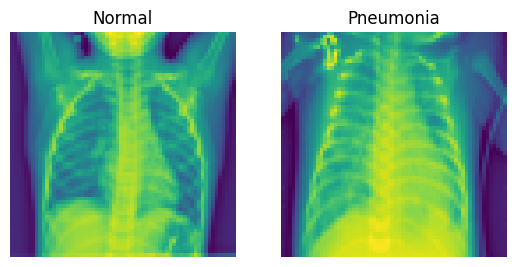

In [63]:
photos = os.listdir("train/NORMAL")
photos2 = os.listdir("train/PNEUMONIA")
first = os.path.join("train/NORMAL",photos[1])
second = os.path.join("train/PNEUMONIA",photos2[1])
imgsize = (64 , 64)
plt.subplot(1,2,1)
plt.imshow(Image.open(first).resize(imgsize))
plt.title("Normal")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(Image.open(second).resize(imgsize))
plt.title("Pneumonia")
plt.axis("off")




## Loading and Preprocessing Images
We load all images, convert them to grayscale, resize them to 64x64, 
and store them as numpy arrays for machine learning.

In [64]:

def loadimages(folder, label):
    X = []
    Y = []
    imgresize = (64,64)
    photos = os.listdir(folder)
    for x in photos:
        if x.endswith(".jpeg"):
          photo = os.path.join(folder,x)
          img = Image.open(photo).convert("L").resize(imgresize)
          X.append(np.array(img))
          Y.append(label)
    return X,Y
  


## Loading All Images
We load all images from train, combine normal and pneumonia into one dataset.

In [65]:

X_normal, Y_normal = loadimages("train/NORMAL", 0)
X_pneumonia, Y_pneumonia = loadimages("train/PNEUMONIA", 1)
X = X_normal + X_pneumonia
Y = Y_normal + Y_pneumonia
print(len(X))
print(len(Y))


5216
5216


## Flattening Images
We convert images from 2D arrays (64x64) to 1D arrays (4096) so ML models can process them.

In [66]:
X = np.array(X)
Y = np.array(Y)
print(X.shape)
X = X.reshape(len(X), -1)
print(X.shape)


(5216, 64, 64)
(5216, 4096)


## PCA - Principal Component Analysis
We reduce the number of features from 4096 to a smaller number while keeping the most important information.

In [67]:
pca = PCA(n_components=100)
X_pca = pca.fit_transform(X)
print(X_pca.shape)

(5216, 100)


## Train/Test Split
We split the training data 80/20. 80% for training, 20% for testing.
The test folder is kept for final evaluation only.

In [68]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_val.shape)
print(len(X_train)/len(X)*100)
print(len(X_val)/len(X)*100)

(4172, 4096)
(1044, 4096)
79.98466257668711
20.015337423312886


## Loading Test Data
We load the test folder images for final evaluation.

In [69]:
X_test_normal, Y_test_normal = loadimages("test/NORMAL", 0)
X_test_pneumonia, Y_test_pneumonia = loadimages("test/PNEUMONIA", 1)
X_test = X_test_normal + X_test_pneumonia
Y_test = Y_test_normal + Y_test_pneumonia
print(len(X_test))

624
